### Tasks

* 1. Load the 'Mall Customers' dataset (or any small customer dataset) and apply the DBSCAN algorithm using scikit-learn to cluster users based on their annual income and spending score. Print the number of clusters found and the number of noise points detected.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons

In [2]:
df = pd.read_csv(r"C:\Users\patel prit\OneDrive\Desktop\Assessment\ML\Assignment\Unsupervised\Session - 3\Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

In [6]:
dbscan = DBSCAN(eps=9, min_samples=5)
clusters = dbscan.fit_predict(X)

In [7]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

In [8]:
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points detected: {n_noise}")

Number of clusters found: 6
Number of noise points detected: 23


* 2. Visualize the DBSCAN clustering results from your previous task using matplotlib — plot each cluster in a different color, and mark noise points in black. Add axis labels and a legend for clarity.

In [9]:
unique_clusters = set(clusters)
colors = plt.cm.get_cmap("tab10", len(unique_clusters))

C:\Users\patel prit\AppData\Local\Temp\ipykernel_18060\2087165360.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_clusters))


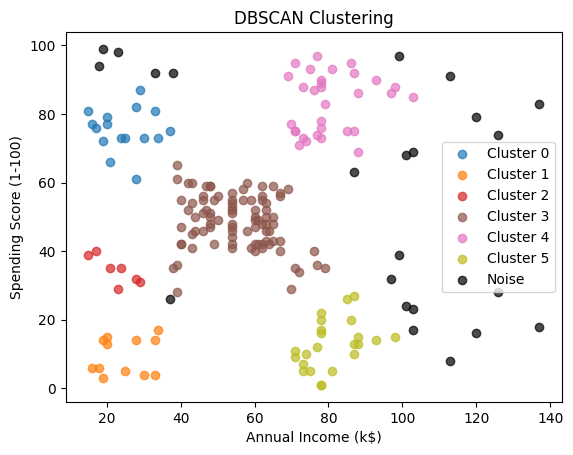

In [10]:
for cluster_id in unique_clusters:
    if cluster_id == -1:
        color = "black"
        label = "Noise"
    else:
        color = colors(cluster_id)
        label = f"Cluster {cluster_id}"
    
    cluster_points = X[clusters == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=[color], label=label, alpha=0.7)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

* 3. Change the DBSCAN parameters (eps and min_samples) to see how the number of clusters and noise points change. Write a short summary (3-4 lines) explaining how parameter choices affect the clustering outcome for your dataset.<br><br><em><strong>Hint:</strong> Try at least two different values for eps and min_samples, and compare results.</em>

In [11]:
dbscan_strict = DBSCAN(eps=5, min_samples=10)
clusters_strict = dbscan_strict.fit_predict(X)

dbscan_loose = DBSCAN(eps=15, min_samples=3)
clusters_loose = dbscan_loose.fit_predict(X)

print("Strict Clusters:", len(set(clusters_strict)) - (1 if -1 in clusters_strict else 0), "Noise:", list(clusters_strict).count(-1))
print("Loose Clusters:", len(set(clusters_loose)) - (1 if -1 in clusters_loose else 0), "Noise:", list(clusters_loose).count(-1))

Strict Clusters: 1 Noise: 133
Loose Clusters: 1 Noise: 0


* 4. Compare DBSCAN and K-Means on the same dataset: run both algorithms, plot their cluster assignments side by side, and briefly note which method better handles outliers or oddly-shaped clusters.<br><br><em><strong>Constraint:</strong> Use the same features and number of clusters (for K-Means) as you observed with DBSCAN.</em>

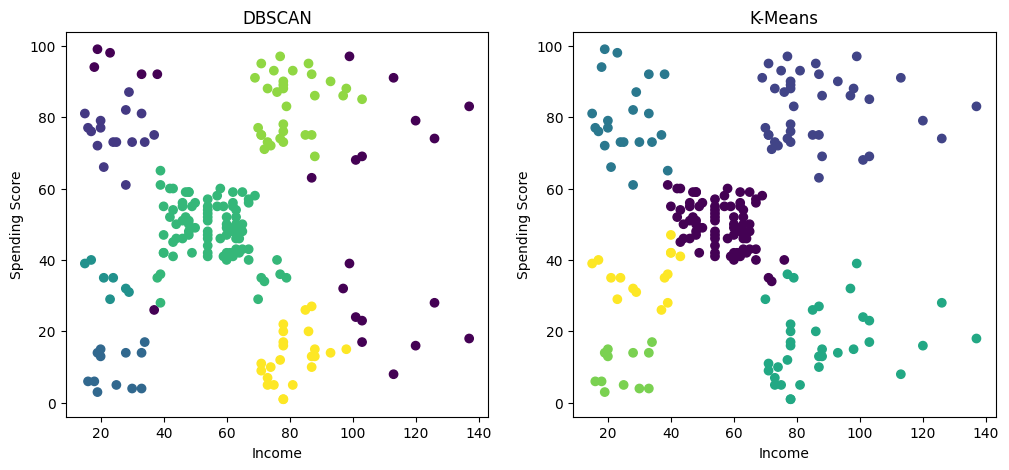

In [12]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_clusters = kmeans.fit_predict(X)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=clusters, cmap="viridis")
axes[0].set_title("DBSCAN")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Spending Score")

axes[1].scatter(X[:, 0], X[:, 1], c=kmeans_clusters, cmap="viridis")
axes[1].set_title("K-Means")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Spending Score")

plt.show()

### Comparison
DBSCAN handles outliers much better by isolating them as noise (the black points), whereas K-Means is forced to assign every single outlier to the nearest cluster, which can skew the cluster's center. DBSCAN is also capable of capturing oddly-shaped clusters based on density, while K-Means assumes clusters are always spherical.

* 5. Pick a dataset with non-spherical clusters (e.g., make_moons or make_circles from sklearn.datasets), and use DBSCAN to cluster the data. Identify and print the indices of all points labeled as noise (outliers).

In [13]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)

In [14]:
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)

In [15]:
moon_clusters = dbscan_moons.fit_predict(X_moons)

In [17]:
noise_indices = np.where(moon_clusters == -1)[0]
noise_indices

array([ 78, 197])